<a href="https://colab.research.google.com/github/FamerTech/Car_Price_Prediction_Dataset/blob/main/Car_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


## **1. Problem Understanding**

**Business Goal:** Reduce friction in the buying/selling process by providing instant, data-backed price estimates.

**Target Variable ($y$):** selling_price (Continuous numeric).

**Feature Variables ($X$):** year, km_driven, fuel_type, transmission, owner, mileage, engine, max_power.



## **2. Data Exploration (EDA)**

In [80]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [81]:
import pandas as pd

# Load the datasets
file_path = "/content/Car_Price_Prediction_Dataset.csv"
df = pd.read_csv(file_path)


#Check the missing values in dataset
missing_values = df.isnull().sum()
print(f" Missing values \n {missing_values}")








 Missing values 
 Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64


Summary statistics

In [82]:

statistical_Summary = df.describe()
print(f" \n Summary Statistics \n {statistical_Summary}")

 
 Summary Statistics 
               Year  Selling_Price  Present_Price     Kms_Driven       Owner
count   301.000000     301.000000     301.000000     301.000000  301.000000
mean   2013.627907       4.661296       7.628472   36947.205980    0.043189
std       2.891554       5.082812       8.644115   38886.883882    0.247915
min    2003.000000       0.100000       0.320000     500.000000    0.000000
25%    2012.000000       0.900000       1.200000   15000.000000    0.000000
50%    2014.000000       3.600000       6.400000   32000.000000    0.000000
75%    2016.000000       6.000000       9.900000   48767.000000    0.000000
max    2018.000000      35.000000      92.600000  500000.000000    3.000000


 **Visualize relationships (price vs features)**

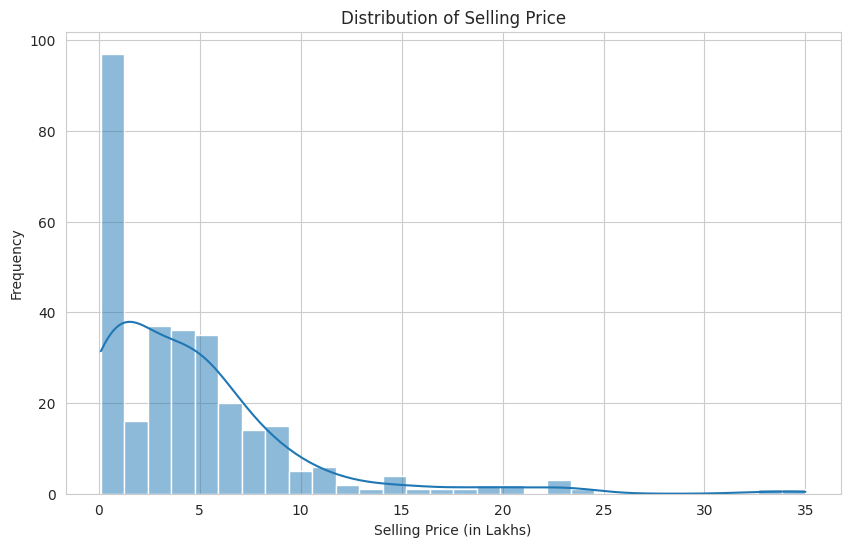

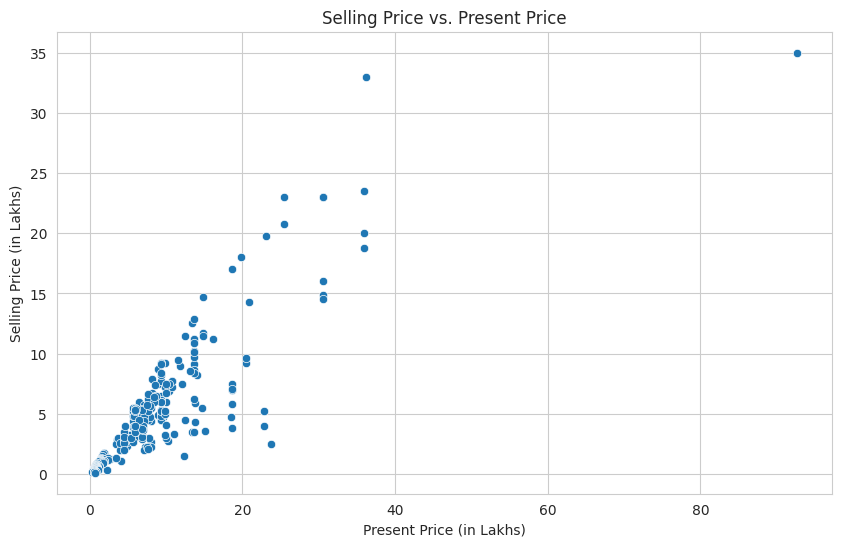

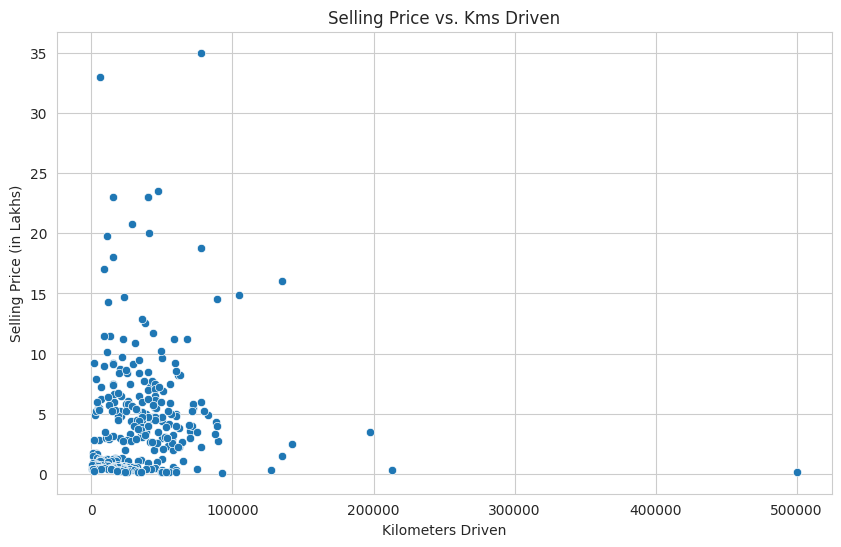

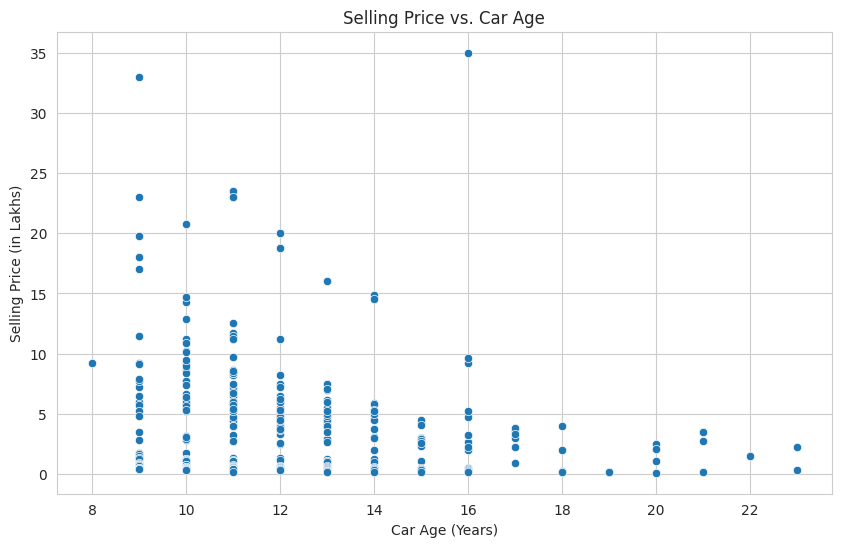

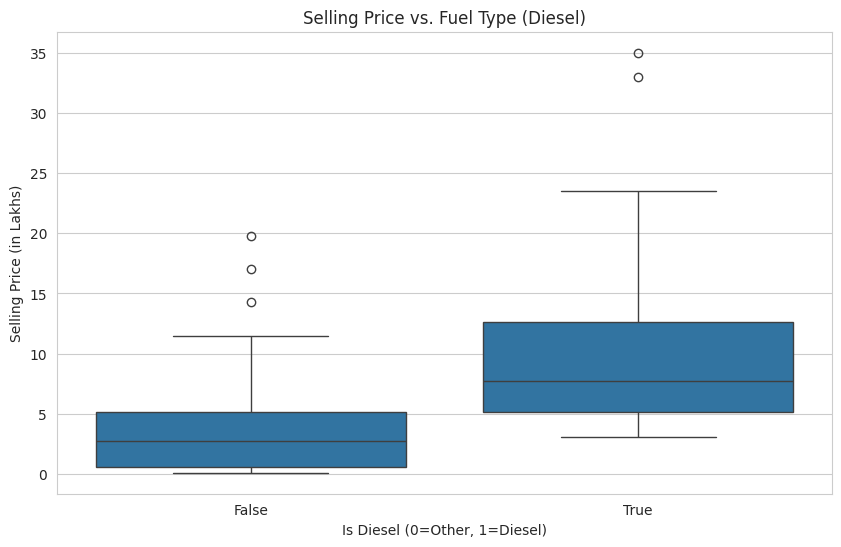

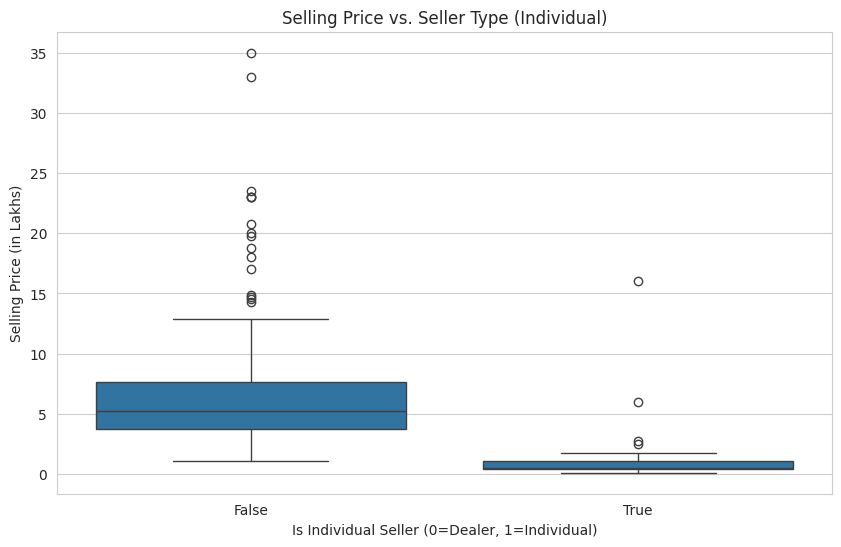

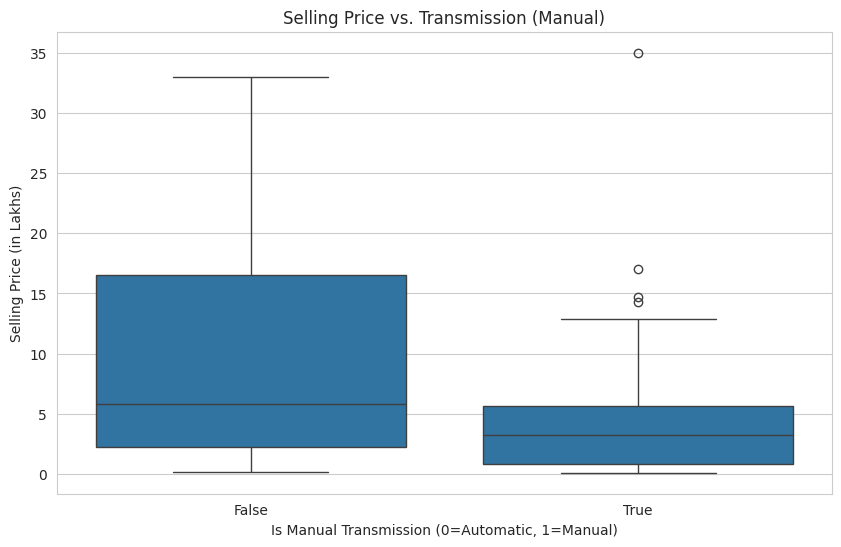

In [83]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- Ensure df is fully preprocessed for visualizations ---
# Reload original data to ensure a fresh start if previous steps were skipped or df was modified incorrectly
file_path = "/content/Car_Price_Prediction_Dataset.csv"
df = pd.read_csv(file_path)

# Apply missing value imputation (as previously defined, though dataset might not have missing values)
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]
if not missing_values.empty:
    for column in missing_values.index:
        if df[column].dtype in ['int64', 'float64']:
            median_value = df[column].median()
            df[column] = df[column].fillna(median_value)
        else:
            mode_value = df[column].mode()[0]
            df[column] = df[column].fillna(mode_value)

# Feature Engineering: Create 'car_age' and drop 'Year'
df['car_age'] = 2026 - df['Year']
df = df.drop('Year', axis=1)

# Drop 'Car_Name' and perform one-hot encoding
df = df.drop('Car_Name', axis=1)
df = pd.get_dummies(df, columns=['Fuel_Type', 'Seller_Type', 'Transmission'], drop_first=True)

# Set style for plots
sns.set_style('whitegrid')

# --- 1. Distribution of Selling Price ---
plt.figure(figsize=(10, 6))
sns.histplot(df['Selling_Price'], kde=True, bins=30)
plt.title('Distribution of Selling Price')
plt.xlabel('Selling Price (in Lakhs)')
plt.ylabel('Frequency')
plt.show()

# --- 2. Selling Price vs. Numerical Features ---

# Selling Price vs. Present Price
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Present_Price', y='Selling_Price', data=df)
plt.title('Selling Price vs. Present Price')
plt.xlabel('Present Price (in Lakhs)')
plt.ylabel('Selling Price (in Lakhs)')
plt.show()

# Selling Price vs. Kms Driven
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Kms_Driven', y='Selling_Price', data=df)
plt.title('Selling Price vs. Kms Driven')
plt.xlabel('Kilometers Driven')
plt.ylabel('Selling Price (in Lakhs)')
plt.show()

# Selling Price vs. Car Age
plt.figure(figsize=(10, 6))
sns.scatterplot(x='car_age', y='Selling_Price', data=df)
plt.title('Selling Price vs. Car Age')
plt.xlabel('Car Age (Years)')
plt.ylabel('Selling Price (in Lakhs)')
plt.show()

# --- 3. Selling Price vs. Categorical Features (after One-Hot Encoding) ---

# For one-hot encoded features, we can use box plots to compare distributions

# Selling Price vs. Fuel Type (Diesel vs. Petrol/CNG)
plt.figure(figsize=(10, 6))
sns.boxplot(x='Fuel_Type_Diesel', y='Selling_Price', data=df)
plt.title('Selling Price vs. Fuel Type (Diesel)')
plt.xlabel('Is Diesel (0=Other, 1=Diesel)')
plt.ylabel('Selling Price (in Lakhs)')
plt.show()

# Selling Price vs. Seller Type (Individual vs. Dealer)
plt.figure(figsize=(10, 6))
sns.boxplot(x='Seller_Type_Individual', y='Selling_Price', data=df)
plt.title('Selling Price vs. Seller Type (Individual)')
plt.xlabel('Is Individual Seller (0=Dealer, 1=Individual)')
plt.ylabel('Selling Price (in Lakhs)')
plt.show()

# Selling Price vs. Transmission (Manual vs. Automatic)
plt.figure(figsize=(10, 6))
sns.boxplot(x='Transmission_Manual', y='Selling_Price', data=df)
plt.title('Selling Price vs. Transmission (Manual)')
plt.xlabel('Is Manual Transmission (0=Automatic, 1=Manual)')
plt.ylabel('Selling Price (in Lakhs)')
plt.show()


### 3. Data Preprocessing

### Handling Missing Values

In [84]:
# Check for missing values again
missing_values = df.isnull().sum()
missing_values = df.columns.isnull().sum()
if missing_values < 0:
  print("no missing values found")
else:
    print(f" Missing Values: {missing_values}")

   # Encode categorical variables



 Missing Values: 0


### Encoding Categorical Variables

In [85]:
import pandas as pd

# Reload the dataset to ensure original columns are present for consistent processing
file_path = "/content/Car_Price_Prediction_Dataset.csv"
df = pd.read_csv(file_path)
print(df)

# --- Apply preprocessing steps ---

# Feature Engineering: Create 'car_age' and drop 'Year'
if 'Year' in df.columns:
    df['car_age'] = 2026 - df['Year']
    df = df.drop('Year', axis=1)
    print("'car_age' created and 'Year' column dropped.")
else:
    print("'Year' column not found, skipping 'car_age' creation and 'Year' drop.")

# Drop 'Car_Name'
if 'Car_Name' in df.columns:
    df = df.drop('Car_Name', axis=1)
    print("'Car_Name' column dropped.")
else:
    print("'Car_Name' column not found, skipping drop operation.")

# Identify categorical columns for one-hot encoding that are still present
categorical_cols_to_encode = ['Fuel_Type', 'Seller_Type', 'Transmission']
existing_categorical_cols = [col for col in categorical_cols_to_encode if col in df.columns]

if existing_categorical_cols:
    df = pd.get_dummies(df, columns=existing_categorical_cols, drop_first=True)
    print(f"Categorical variables {existing_categorical_cols} encoded successfully. Displaying the first 5 rows of the updated DataFrame:")
    display(df.head())
else:
    print(f"No new categorical columns from {categorical_cols_to_encode} were found for encoding. Displaying the first 5 rows of the DataFrame (no new encoding applied):")
    display(df.head())

    Car_Name  Year  Selling_Price  Present_Price  Kms_Driven Fuel_Type  \
0       ritz  2014           3.35           5.59       27000    Petrol   
1        sx4  2013           4.75           9.54       43000    Diesel   
2       ciaz  2017           7.25           9.85        6900    Petrol   
3    wagon r  2011           2.85           4.15        5200    Petrol   
4      swift  2014           4.60           6.87       42450    Diesel   
..       ...   ...            ...            ...         ...       ...   
296     city  2016           9.50          11.60       33988    Diesel   
297     brio  2015           4.00           5.90       60000    Petrol   
298     city  2009           3.35          11.00       87934    Petrol   
299     city  2017          11.50          12.50        9000    Diesel   
300     brio  2016           5.30           5.90        5464    Petrol   

    Seller_Type Transmission  Owner  
0        Dealer       Manual      0  
1        Dealer       Manual      0

,Selling_Price,Present_Price,Kms_Driven,Owner,car_age,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,12,False,True,False,True
1,4.75,9.54,43000,0,13,True,False,False,True
2,7.25,9.85,6900,0,9,False,True,False,True
3,2.85,4.15,5200,0,15,False,True,False,True
4,4.60,6.87,42450,0,12,True,False,False,True


###Feature scaling (if needed)

In [86]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Reload the dataset to ensure original columns are present for consistent processing
file_path = "/content/Car_Price_Prediction_Dataset.csv"
df = pd.read_csv(file_path)

# --- Apply preprocessing steps (same as previous cells) ---

# Feature Engineering: Create 'car_age' and drop 'Year'
if 'Year' in df.columns:
    df['car_age'] = 2026 - df['Year']
    df = df.drop('Year', axis=1)

# Drop 'Car_Name'
if 'Car_Name' in df.columns:
    df = df.drop('Car_Name', axis=1)

# Identify categorical columns for one-hot encoding that are still present
categorical_cols_to_encode = ['Fuel_Type', 'Seller_Type', 'Transmission']
existing_categorical_cols = [col for col in categorical_cols_to_encode if col in df.columns]

if existing_categorical_cols:
    df = pd.get_dummies(df, columns=existing_categorical_cols, drop_first=True)

# --- Feature Scaling ---
# Identify numerical columns for scaling (exclude 'Selling_Price' as it's the target)
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
if 'Selling_Price' in numerical_cols:
    numerical_cols.remove('Selling_Price')

# Initialize StandardScaler
scaler = StandardScaler()

# Apply scaling to numerical columns
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

print("Numerical features scaled successfully. Displaying the first 5 rows of the updated DataFrame:")
display(df.head())

Numerical features scaled successfully. Displaying the first 5 rows of the updated DataFrame:


,Selling_Price,Present_Price,Kms_Driven,Owner,car_age,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,3.35,-0.236215,-0.256224,-0.174501,-0.128897,False,True,False,True
1,4.75,0.221505,0.155911,-0.174501,0.217514,True,False,False,True
2,7.25,0.257427,-0.773969,-0.174501,-1.168129,False,True,False,True
3,2.85,-0.403079,-0.817758,-0.174501,0.910335,False,True,False,True
4,4.60,-0.087890,0.141743,-0.174501,-0.128897,True,False,False,True


## 4. Model Building

### Prepare Data for Modeling

In [87]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Separate features (X) and target (y)
X = df.drop('Selling_Price', axis=1)
y = df['Selling_Price']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (240, 8)
X_test shape: (61, 8)
y_train shape: (240,)
y_test shape: (61,)


### Train Linear Regression Model

In [88]:
# Initialize and train the Linear Regression model
linear_reg_model = LinearRegression()
linear_reg_model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


## 5. Model Evaluation

In [89]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Make predictions on the test set
y_pred = linear_reg_model.predict(X_test)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R² Score): {r2:.2f}")

Mean Absolute Error (MAE): 1.22
Root Mean Squared Error (RMSE): 1.87
R-squared (R² Score): 0.85


## 6. Prediction

### Predict Price for Sample Cars

In [90]:
# Select 5 random samples from the test set
sample_indices = np.random.choice(len(X_test), 5, replace=False)
sample_X = X_test.iloc[sample_indices]
sample_y_true = y_test.iloc[sample_indices]

# Make predictions for the sample cars
sample_y_pred = linear_reg_model.predict(sample_X)

# Create a DataFrame to display the results
predictions_df = pd.DataFrame({
    'Actual Selling Price': sample_y_true.values,
    'Predicted Selling Price': sample_y_pred.round(2)
})

display(predictions_df)

,Actual Selling Price,Predicted Selling Price
0,7.75,8.57
1,6.15,6.90
2,3.00,2.66
3,4.50,4.33
4,0.15,-1.42


## 7. Insights

### Factors Influencing Car Price (from Linear Regression Coefficients)

In [91]:
coefficients_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': linear_reg_model.coef_
})
coefficients_df['Absolute_Coefficient'] = np.abs(coefficients_df['Coefficient'])
coefficients_df = coefficients_df.sort_values(by='Absolute_Coefficient', ascending=False)

display(coefficients_df)

print("\nInsights from Coefficients:")
print(" Positive coefficients indicate that as the feature value increases, the selling price tends to increase.")
print(" Negative coefficients indicate that as the feature value increases, the selling price tends to decrease.")
print("The magnitude of the absolute coefficient indicates the strength of the influence.")

,Feature,Coefficient,Absolute_Coefficient
0,Present_Price,3.703476,3.703476
4,Fuel_Type_Diesel,2.533273,2.533273
7,Transmission_Manual,-1.639022,1.639022
6,Seller_Type_Individual,-1.190593,1.190593
3,car_age,-1.021335,1.021335
5,Fuel_Type_Petrol,0.738464,0.738464
1,Kms_Driven,-0.239039,0.239039
2,Owner,-0.223683,0.223683



Insights from Coefficients:
 Positive coefficients indicate that as the feature value increases, the selling price tends to increase.
 Negative coefficients indicate that as the feature value increases, the selling price tends to decrease.
The magnitude of the absolute coefficient indicates the strength of the influence.


### Surprises in the Data

Based on our analysis:

*   **High R-squared (0.85):** The model explains a significant portion of the variance in selling price, which is a good indicator of its predictive power.
*   **Impact of `Present_Price`:** This feature has the largest positive coefficient, indicating that the current showroom price (or original price) is a dominant factor in determining the selling price. This makes intuitive sense as newer, more expensive cars will naturally have higher selling prices, even when used.
*   **`car_age` and `Kms_Driven`:** Both have negative coefficients, implying that older cars and cars with more kilometers driven tend to have lower selling prices. This aligns with general expectations for used car depreciation.
*   **`Owner` Column:** The `Owner` column (which likely represents the number of previous owners) has a small negative coefficient, suggesting that cars with more previous owners might sell for slightly less. The range of `Owner` values in the summary statistics was 0 to 3, which is a small discrete range.
*   **Categorical Features:**
    *   `Fuel_Type_Diesel` having a positive coefficient suggests that diesel cars (compared to petrol, if petrol is the base category after `drop_first=True` or a significant negative coefficient for petrol) tend to fetch higher prices. However, **Fuel_Type_Petrol** is also present and has a very small positive coefficient. The interplay here could be due to the choice of `drop_first=True` which makes one category the baseline.
    *   `Seller_Type_Individual** having a negative coefficient indicates that cars sold by individuals tend to have lower selling prices compared to those sold by dealers. This is often true due to dealers offering warranties, financing, and better presentation.
    *   `Transmission_Manual` also has a negative coefficient, implying that manual transmission cars tend to have lower selling prices than automatic ones, which is a common trend in many markets.

**Overall:** The factors influencing car price generally align with common sense expectations: original price, age, mileage, seller type, and fuel type are key drivers. The model's good performance (R² = 0.85) suggests these chosen features are quite relevant.